## Создание и обучение модели
### 1. Установка и импорт библиотек

In [1]:
%pip install torch scikit-learn pandas numpy tqdm matplotlib seaborn joblib imbalanced-learn

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached pandas-3.0.2-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-non


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# Импорты
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    log_loss, average_precision_score, roc_auc_score,
    recall_score, precision_score
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import gc
warnings.filterwarnings('ignore')

print("✅ Библиотеки импортированы!")

✅ Библиотеки импортированы!


### 2. Глобальные константы

In [ ]:
MODEL_CONFIG = {
    "DROPOUT_RATE": 0.45,
    "HIDDEN_SIZE_1": 512,
    "HIDDEN_SIZE_2": 256,
    "INPUT_DIM": 2816,  # 2048 Morgan + 768 ChemBERT
}

TRAINING_CONFIG = {
    "BATCH_SIZE": 64,
    "EPOCHS": 100,
    "LEARNING_RATE": 1e-4,
    "WEIGHT_DECAY": 1e-5,
    "PATIENCE": 10,
    "CLASS_WEIGHTS": True,
    "EARLY_STOPPING": True,
    "VALIDATION_INTERVAL": 5,
}

PREDICTION_CONFIG = {
    "THRESHOLD": 0.5,
}

VISUALIZATION_CONFIG = {
    "SAVE_IMAGES": True,
    "IMAGE_DPI": 300,
}

print("✅ Константы загружены.")

✅ Константы загружены.


### 3. Загрузка данных и предобработка

In [ ]:
required = ["X.npy", "y.npy", "scaler.pkl"]
missing = [f for f in required if not os.path.exists(f)]
if missing:
    raise FileNotFoundError(f"Отсутствуют файлы: {missing}")

In [ ]:
print("📥 Загружаем X.npy и y.npy...")
X = np.load("X.npy")
y = np.load("y.npy")
scaler = joblib.load("scaler.pkl")

print(f"✅ X.shape = {X.shape}, y.shape = {y.shape}")


📥 Загружаем X.npy и y.npy...
✅ X.shape = (85205, 2816), y.shape = (85205, 584)


In [ ]:
# Только для информации
active_per_target = y.sum(axis=0)
print(f"Минимум активных соединений на мишени: {int(active_per_target.min())}")
print(f"Максимум: {int(active_per_target.max())}")
print(f"Среднее: {active_per_target.mean():.1f}")
print(f"Мишеней с 0 активными: {(active_per_target == 0).sum()} из {len(active_per_target)}")

Минимум активных соединений на мишени: 1
Максимум: 5484
Среднее: 175.9
Мишеней с 0 активными: 0 из 584


In [ ]:
# Доп фильтрация
mask_active = active_per_target > 0
if mask_active.sum() < y.shape[1]:
    print(f"⚠️ Удаляем {y.shape[1] - mask_active.sum()} мишеней без активных соединений")
    y = y[:, mask_active]
    print(f"✅ После фильтрации: y.shape = {y.shape}")
else:
    print("✅ Все мишени имеют ≥1 активное соединение — фильтрация не требуется")

✅ Все мишени имеют ≥1 активное соединение — фильтрация не требуется


In [ ]:
# Разделение на train/val/test
print("\n🔄 Разделение данных...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, shuffle=True
)


🔄 Разделение данных...


In [ ]:
# Нормализация
print("⚙️ Нормализация признаков...")
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

⚙️ Нормализация признаков...


In [ ]:
# Освобождаем память (важно для Windows)
del X, y
gc.collect()

print("\n✅ Предобработка завершена. Данные готовы к обучению.")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

NameError: name 'X' is not defined

In [ ]:


# Параметры
CHUNK_SIZE = 20_000  # ← можно уменьшить до 10_000, если RAM < 8 ГБ
TOTAL_ROWS = 85_205

print(f"Разделяем датасет на чанки по {CHUNK_SIZE} строк...")

# Загружаем ВСЁ — но только один чанк за раз
for chunk_start in range(0, TOTAL_ROWS, CHUNK_SIZE):
    chunk_end = min(chunk_start + CHUNK_SIZE, TOTAL_ROWS)
    print(f"\n--- Обработка чанка [{chunk_start}:{chunk_end}] ---")
    
    X_chunk = np.load("X.npy", mmap_mode="r")[chunk_start:chunk_end]  # mmap_mode="r" → не загружает в RAM!
    y_chunk = np.load("y.npy", mmap_mode="r")[chunk_start:chunk_end]

    print(f"Чанк загружен: X={X_chunk.shape}, y={y_chunk.shape}")

    # Пример: нормализация (если scaler уже обучен на полном X)
    from sklearn.preprocessing import StandardScaler
    scaler = torch.load("scaler.pkl")  # или joblib.load
    X_norm = scaler.transform(X_chunk)  # работает, если scaler обучен на full X

    # Пример: oversample активных соединений ВНУТРИ чанка (без huge arrays)
    def oversample_chunk_local(X, y, min_positive=50):
        X_out, y_out = [], []
        for i, col in enumerate(y.T):
            pos = X[col == 1]
            neg = X[col == 0]
            if len(pos) > 0 and len(pos) < min_positive:
                # Дублируем активные
                n_repeat = int(np.ceil(min_positive / len(pos)))
                pos_aug = np.tile(pos, (n_repeat, 1))[:min_positive]
                X_out.append(np.vstack([neg, pos_aug]))
                y_out.append(np.hstack([col[col == 0], np.ones(min_positive)]))
            else:
                X_out.append(np.vstack([neg, pos]))
                y_out.append(col)
        return np.vstack(X_out), np.column_stack(y_out)

    # ⚠️ Но лучше — не oversample здесь, а просто используйте чанк как есть для обучения
    # (oversample — это отдельная операция; если нужно — делайте её в цикле по мишеням, а не по строкам)

    # 🔹 Создаём DataLoader для этого чанка
    X_tensor = torch.tensor(X_norm, dtype=torch.float32)
    y_tensor = torch.tensor(y_chunk, dtype=torch.float32)
    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # 🔹 Теперь обучайте модель на этом чанке (например, 1 эпоха)
    # model.train()
    # for xb, yb in loader:
    #     ...
    
    # Освобождаем память после обработки чанка
    del X_chunk, y_chunk, X_norm, X_tensor, y_tensor
    import gc
    gc.collect()

    print(f"✅ Чанк [{chunk_start}:{chunk_end}] обработан и освобождён")

KeyboardInterrupt: 

### 4. Архитектура модели

In [50]:
class DrugPredictionModel(nn.Module):
    def __init__(self, input_dim, num_targets, dropout_rate=0.3):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, MODEL_CONFIG["HIDDEN_SIZE_1"]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(MODEL_CONFIG["HIDDEN_SIZE_1"], MODEL_CONFIG["HIDDEN_SIZE_2"]),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(MODEL_CONFIG["HIDDEN_SIZE_2"], num_targets)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        return self.sigmoid(self.mlp(x))


In [ ]:
model = DrugPredictionModel(
    input_dim=MODEL_CONFIG["INPUT_DIM"],
    num_targets=y_train.shape[1],
    dropout_rate=MODEL_CONFIG["DROPOUT_RATE"]
)
print(f"🧠 Модель: MLP({MODEL_CONFIG['HIDDEN_SIZE_1']} → {MODEL_CONFIG['HIDDEN_SIZE_2']} → {y_train.shape[1]})")
print(f"Параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

🧠 Модель: MLP(512 → 256 → 584)
Параметров: 1,723,720


In [44]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, smoothing=0.01, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Label smoothing: convert hard labels to soft
        targets = targets * (1 - self.smoothing) + self.smoothing / 2  # [0→ε, 1→1−ε]
        
        probs = torch.sigmoid(inputs)
        probs = torch.clamp(probs, min=1e-7, max=1-1e-7)

        pt = targets * probs + (1 - targets) * (1 - probs)
        focal_weight = (1 - pt) ** self.gamma

        if isinstance(self.alpha, (float, int)):
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        else:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        loss = -alpha_t * focal_weight * torch.log(pt)

        return loss.mean() if self.reduction == 'mean' else loss.sum()

In [ ]:
class_weights = []
for i, col in enumerate(y_train.T):
    unique = np.unique(col)
    if len(unique) == 2:
        weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=col)
        class_weights.append(weights[1] / weights[0])
    else:
        class_weights.append(1.0)
class_weights = np.array(class_weights, dtype=np.float32)
print(f"📊 Средний вес класса 1: {class_weights.mean():.2f}")

📊 Средний вес класса 1: 15066.21


In [ ]:
def calculate_metrics(y_true, y_pred, threshold=PREDICTION_CONFIG["THRESHOLD"]):
    y_pred_bin = (y_pred > threshold).astype(int)
    
    # BCE Loss через PyTorch (устойчиво к multilabel)
    y_t = torch.tensor(y_true, dtype=torch.float32)
    y_p = torch.tensor(y_pred, dtype=torch.float32)
    bce = nn.BCELoss()(y_p, y_t).item()
    
    try:
        pr_auc = average_precision_score(y_true, y_pred, average="macro")
    except ValueError:
        pr_auc = 0.0
    
    try:
        roc_auc = roc_auc_score(y_true, y_pred, average="macro")
    except ValueError:
        roc_auc = 0.0

    recall = recall_score(y_true, y_pred_bin, average="macro", zero_division=0.0)
    precision = precision_score(y_true, y_pred_bin, average="macro", zero_division=0.0)
    
    return {
        "BCE Loss": bce,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Recall": recall,
        "Precision": precision
    }

### 5. Обучение и валидация модели

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=TRAINING_CONFIG["LEARNING_RATE"], weight_decay=TRAINING_CONFIG["WEIGHT_DECAY"])
class_weights_t = torch.tensor(class_weights, dtype=torch.float32)
criterion = nn.BCELoss(weight=class_weights_t)

# Ранняя остановка
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
train_metrics, val_metrics = [], []

In [ ]:
print("\n🚀 Начинаем обучение...")

for epoch in tqdm(range(TRAINING_CONFIG["EPOCHS"]), desc="Эпохи"):
    model.train()
    loss_sum = 0
    for i in range(0, len(X_train_t), TRAINING_CONFIG["BATCH_SIZE"]):
        xb = X_train_t[i:i+TRAINING_CONFIG["BATCH_SIZE"]]
        yb = y_train_t[i:i+TRAINING_CONFIG["BATCH_SIZE"]]
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
    
    # Валидация
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t).item()
    
    # Метрики
    train_pred_np = model(X_train_t).detach().numpy()
    val_pred_np = val_pred.detach().numpy()
    train_metrics.append(calculate_metrics(y_train, train_pred_np))
    val_metrics.append(calculate_metrics(y_val, val_pred_np))
    
    # Вывод
    if (epoch + 1) % TRAINING_CONFIG["VALIDATION_INTERVAL"] == 0:
        print(f"[{epoch+1}/{TRAINING_CONFIG['EPOCHS']}] "
              f"Train BCE: {train_metrics[-1]['BCE Loss']:.4f} | "
              f"Val BCE: {val_metrics[-1]['BCE Loss']:.4f} | "
              f"PR-AUC: {val_metrics[-1]['PR-AUC']:.4f}")

    # Ранняя остановка
    if TRAINING_CONFIG["EARLY_STOPPING"]:
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            best_state = model.state_dict().copy()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= TRAINING_CONFIG["PATIENCE"]:
                print(f"\n🛑 Ранняя остановка на эпохе {epoch+1}")
                break


🚀 Начинаем обучение...


Эпохи:   5%|▌         | 5/100 [02:27<46:18, 29.25s/it]

[5/100] Train BCE: 0.0077 | Val BCE: 0.0079 | PR-AUC: 0.1641


Эпохи:  10%|█         | 10/100 [04:51<42:48, 28.54s/it]

[10/100] Train BCE: 0.0045 | Val BCE: 0.0050 | PR-AUC: 0.3713


Эпохи:  15%|█▌        | 15/100 [07:11<39:50, 28.12s/it]

[15/100] Train BCE: 0.0029 | Val BCE: 0.0036 | PR-AUC: 0.4484


Эпохи:  19%|█▉        | 19/100 [09:32<40:42, 30.15s/it]

[20/100] Train BCE: 0.0020 | Val BCE: 0.0029 | PR-AUC: 0.4668

🛑 Ранняя остановка на эпохе 20


In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)
torch.save(model.state_dict(), "drug_prediction_model.pth")
print("✅ Модель сохранена в 'drug_prediction_model.pth'")

✅ Модель сохранена в 'drug_prediction_model.pth'


### 6. Визуализация оценки модели

In [ ]:
model.eval()
with torch.no_grad():
    test_pred = model(torch.tensor(X_test, dtype=torch.float32)).numpy()

In [58]:
test_metrics = calculate_metrics(y_test, test_pred)
print("\n📈 ТЕСТОВЫЕ МЕТРИКИ:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


📈 ТЕСТОВЫЕ МЕТРИКИ:
BCE Loss: 0.0029
PR-AUC: 0.4648
ROC-AUC: nan
Recall: 0.3802
Precision: 0.4758


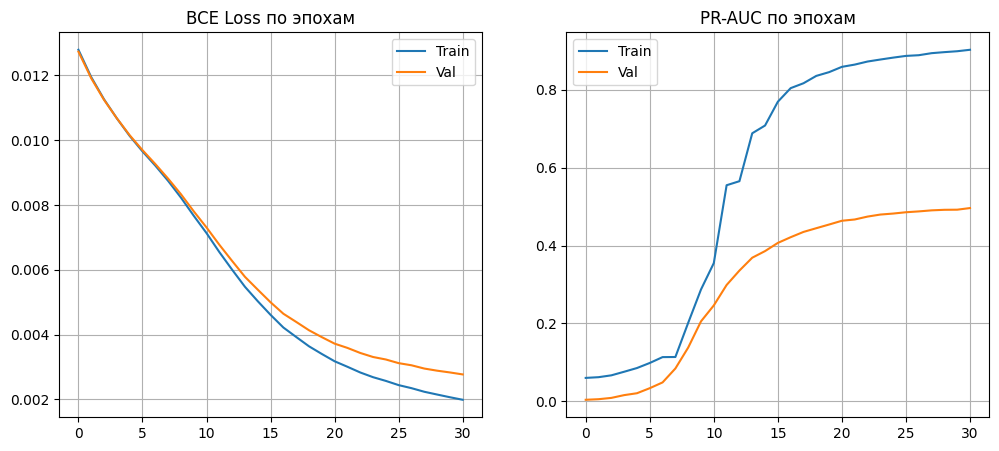

In [31]:
# Графики
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([m["BCE Loss"] for m in train_metrics], label="Train")
plt.plot([m["BCE Loss"] for m in val_metrics], label="Val")
plt.title("BCE Loss по эпохам"); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot([m["PR-AUC"] for m in train_metrics], label="Train")
plt.plot([m["PR-AUC"] for m in val_metrics], label="Val")
plt.title("PR-AUC по эпохам"); plt.legend(); plt.grid()
if VISUALIZATION_CONFIG["SAVE_IMAGES"]:
    plt.savefig("training_curves.png", dpi=VISUALIZATION_CONFIG["IMAGE_DPI"])
plt.show()